In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

ruta = "/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo"
os.chdir(ruta)

In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn import metrics

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [4]:
def regression_metrics(y_true, y_pred):

    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)

    r2 = metrics.r2_score(y_true, y_pred)
    mae = metrics.mean_absolute_error(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = 100 * mae / np.average(y_true)

    return {
        "r2": r2,
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "mape": mape
    }

In [5]:
datasets = {
    "7d_no_info": pd.read_csv("qDiario_7d_no_info.csv"),
    "7d_info": pd.read_csv("qDiario_7d_info.csv"),
    "14d_no_info": pd.read_csv("qDiario_14d_no_info.csv"),
    "14d_info": pd.read_csv("qDiario_14d_info.csv")
}

In [6]:
def prepare_data(df, target_col="m3(t)"):

    df = df.dropna().copy()

    if "Fecha" in df.columns:
        df["Fecha"] = pd.to_datetime(df["Fecha"])
        dates = df["Fecha"]
    else:
        dates = pd.to_datetime(df.index)

    df_numeric = df.select_dtypes(include=[np.number])

    X = df_numeric.drop(columns=[target_col])
    y = df_numeric[target_col]

    split_idx = int(len(df) * 0.8)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    dates_train = dates.iloc[:split_idx]
    dates_test = dates.iloc[split_idx:]

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

    return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, scaler_y, dates_train, dates_test

In [7]:
def reshape_for_lstm(X):
    return X.reshape((X.shape[0], X.shape[1], 1))

In [8]:
def build_lstm_hp(input_shape, units):

    model = keras.Sequential([
        keras.Input(shape=input_shape),

        layers.LSTM(int(units)),
        layers.Dense(16, activation="relu"),

        layers.Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss="mse"
    )

    return model

In [9]:
param_grid = [
    {"units": 48, "batch": 32},
    {"units": 56, "batch": 32},
    {"units": 64, "batch": 40},
    {"units": 64, "batch": 48},
    {"units": 60, "batch": 32},
    {"units": 68, "batch": 32},
]

In [10]:
callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [11]:
def cross_validate_lstm_ts(X_train, y_train, best_params, n_splits=10):

    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

        print(f"Fold {fold+1}")

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        X_tr = reshape_for_lstm(X_tr)
        X_val = reshape_for_lstm(X_val)

        model = build_lstm_hp(
            (X_tr.shape[1], 1),
            best_params["units"]
        )

        model.fit(
            X_tr, y_tr,
            epochs=40,
            batch_size=best_params["batch"],
            verbose=0,
            validation_data=(X_val, y_val)
        )

        y_pred = model.predict(X_val, verbose=0)

        metrics_dict = regression_metrics(y_val, y_pred)
        fold_metrics.append(metrics_dict)

        print(f"  RMSE: {metrics_dict['rmse']:.4f} | MAE: {metrics_dict['mae']:.4f} | MAPE: {metrics_dict['mape']:.2f}")

    return fold_metrics

In [12]:
def cross_validate_lstm_hp(X_train, y_train, params, n_splits=5):

    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = []

    for train_idx, val_idx in tscv.split(X_train):

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        X_tr = reshape_for_lstm(X_tr)
        X_val = reshape_for_lstm(X_val)

        model = build_lstm_hp(
            (X_tr.shape[1], 1),
            params["units"]
        )

        model.fit(
            X_tr, y_tr,
            epochs=80,
            batch_size=params["batch"],
            verbose=0
        )

        y_pred = model.predict(X_val, verbose=0)

        scores.append(regression_metrics(y_val, y_pred)["rmse"])

    return np.mean(scores)

In [13]:
def train_and_predict_train_test_lstm(X_train, y_train, X_test, y_test, scaler_y, best_params):

    X_train_lstm = reshape_for_lstm(X_train)
    X_test_lstm = reshape_for_lstm(X_test)

    model = build_lstm_hp(
        (X_train_lstm.shape[1], 1),
        best_params["units"]
    )

    model.fit(
       X_train_lstm, y_train,
       epochs=100,
       batch_size=best_params["batch"],
       verbose=0
    )

    y_train_pred = model.predict(X_train_lstm, verbose=0)
    y_test_pred = model.predict(X_test_lstm, verbose=0)

    # 🔥 CLAVE: NO desescalar
    y_train_true = y_train
    y_test_true = y_test

    metrics_dict = regression_metrics(y_test_true, y_test_pred)

    return metrics_dict, y_train_true, y_train_pred, y_test_true, y_test_pred

In [14]:
def plot_train_test(dates_train, dates_test,
                    y_train_true, y_train_pred,
                    y_test_true, y_test_pred,
                    title):

    plt.figure(figsize=(14,8))
    n_ticks = 10

    # TRAIN
    plt.subplot(2,1,1)
    plt.plot(dates_train, y_train_true, color="gray", label="Real")
    plt.plot(dates_train, y_train_pred, color="red", label="Predicción")
    plt.title(f"{title} - Train (80%)")
    plt.legend(loc="upper left")

    idx = np.linspace(0, len(dates_train)-1, n_ticks, dtype=int)
    plt.xticks(dates_train.iloc[idx], rotation=45)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))

    # TEST
    plt.subplot(2,1,2)
    plt.plot(dates_test, y_test_true, color="gray", label="Real")
    plt.plot(dates_test, y_test_pred, color="red", label="Predicción")
    plt.title(f"{title} - Test (20%)")
    plt.legend(loc="upper left")

    idx = np.linspace(0, len(dates_test)-1, n_ticks, dtype=int)
    plt.xticks(dates_test.iloc[idx], rotation=45)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))

    plt.tight_layout()
    plt.show()

In [15]:
def plot_boxplots(folds_df):

    order = ["7d_no_info", "7d_info", "14d_no_info", "14d_info"]

    palette = {
        "7d_no_info": "#4C72B0",
        "7d_info": "#55A868",
        "14d_no_info": "#C44E52",
        "14d_info": "#8172B2"
    }

    plt.figure(figsize=(18,5))

    plt.subplot(1,3,1)
    sns.boxplot(data=folds_df, x="dataset", y="rmse",
                order=order, hue="dataset", palette=palette, legend=False)
    plt.title("RMSE")

    plt.subplot(1,3,2)
    sns.boxplot(data=folds_df, x="dataset", y="mae",
                order=order, hue="dataset", palette=palette, legend=False)
    plt.title("MAE")

    plt.subplot(1,3,3)
    sns.boxplot(data=folds_df, x="dataset", y="mape",
                order=order, hue="dataset", palette=palette, legend=False)
    plt.title("MAPE")

    plt.tight_layout()
    plt.show()

In [16]:
hp_results = []

df_hp = datasets["7d_info"]

X_train, _, y_train, _, _, _, _ = prepare_data(df_hp)

for params in param_grid:

    print(f"Testing: {params}")

    score = cross_validate_lstm_hp(X_train, y_train, params)

    hp_results.append({**params, "rmse": score})

hp_df = pd.DataFrame(hp_results).sort_values("rmse")
display(hp_df)

best_params = hp_df.iloc[0].to_dict()

best_params = {
    "units": int(best_params["units"]),
    "batch": int(best_params["batch"])
}

print("Best params:", best_params)

Testing: {'units': 48, 'batch': 32}


Testing: {'units': 56, 'batch': 32}
Testing: {'units': 64, 'batch': 40}
Testing: {'units': 64, 'batch': 48}
Testing: {'units': 60, 'batch': 32}
Testing: {'units': 68, 'batch': 32}


,units,batch,rmse
5,68,32,0.113118
4,60,32,0.114078
1,56,32,0.115617
3,64,48,0.118378
0,48,32,0.118526
2,64,40,0.120518


Best params: {'units': 68, 'batch': 32}



DATASET: 7d_no_info
Fold 1
  RMSE: 0.1045 | MAE: 0.0767 | MAPE: 17.32
Fold 2
  RMSE: 0.0773 | MAE: 0.0602 | MAPE: 26.52
Fold 3
  RMSE: 0.0970 | MAE: 0.0729 | MAPE: 21.64
Fold 4
  RMSE: 0.1345 | MAE: 0.1046 | MAPE: 18.48
Fold 5
  RMSE: 0.0857 | MAE: 0.0612 | MAPE: 15.35
Fold 6
  RMSE: 0.0926 | MAE: 0.0705 | MAPE: 42.75
Fold 7
  RMSE: 0.1349 | MAE: 0.1022 | MAPE: 19.94
Fold 8
  RMSE: 0.0906 | MAE: 0.0689 | MAPE: 20.21
Fold 9
  RMSE: 0.0713 | MAE: 0.0435 | MAPE: 25.56
Fold 10
  RMSE: 0.1411 | MAE: 0.1104 | MAPE: 28.31


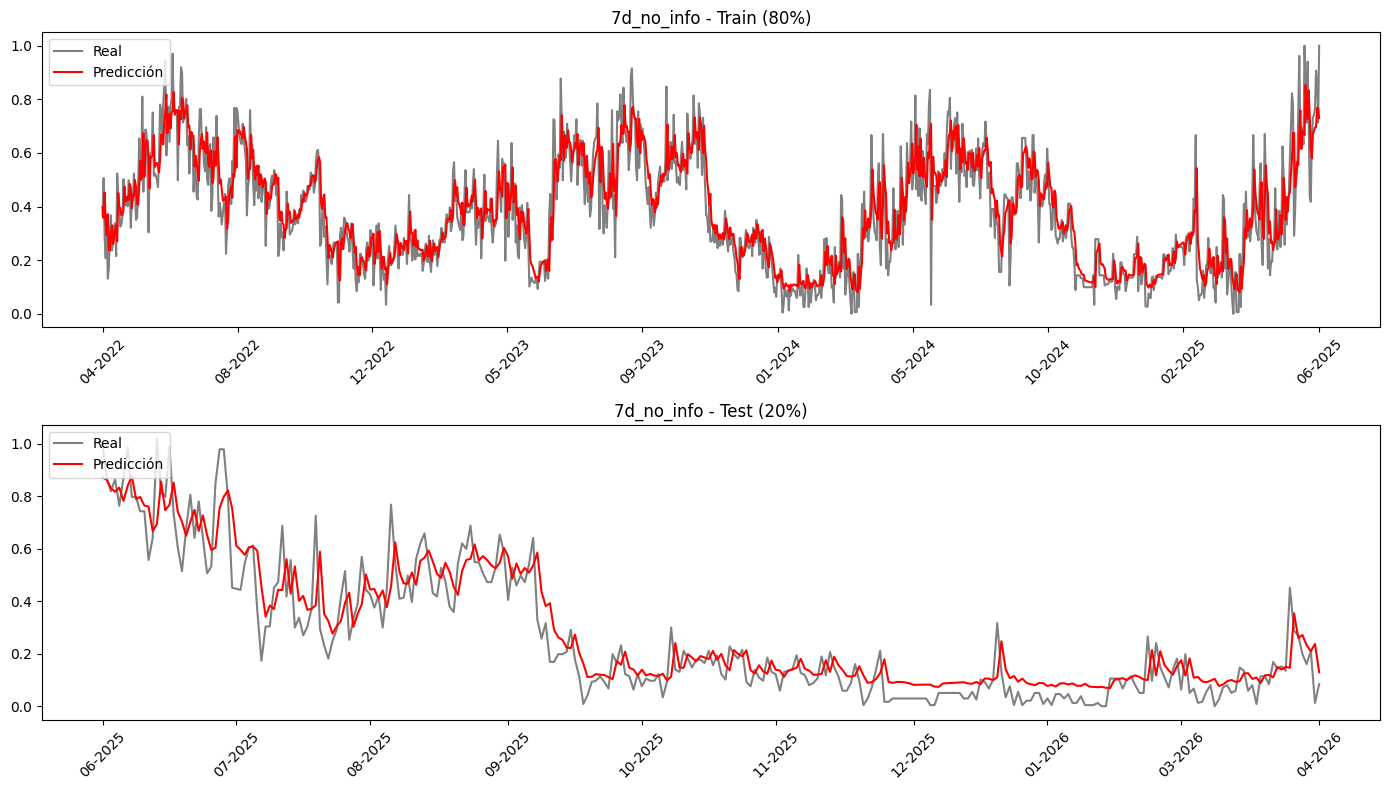


DATASET: 7d_info
Fold 1
  RMSE: 0.1681 | MAE: 0.1336 | MAPE: 30.16
Fold 2
  RMSE: 0.0844 | MAE: 0.0654 | MAPE: 28.80
Fold 3
  RMSE: 0.1262 | MAE: 0.1001 | MAPE: 29.70
Fold 4
  RMSE: 0.1530 | MAE: 0.1190 | MAPE: 21.02
Fold 5
  RMSE: 0.1005 | MAE: 0.0754 | MAPE: 18.91
Fold 6
  RMSE: 0.1071 | MAE: 0.0898 | MAPE: 54.49
Fold 7
  RMSE: 0.1420 | MAE: 0.1103 | MAPE: 21.53
Fold 8
  RMSE: 0.1082 | MAE: 0.0873 | MAPE: 25.62
Fold 9
  RMSE: 0.0915 | MAE: 0.0648 | MAPE: 38.09
Fold 10
  RMSE: 0.1551 | MAE: 0.1235 | MAPE: 31.66


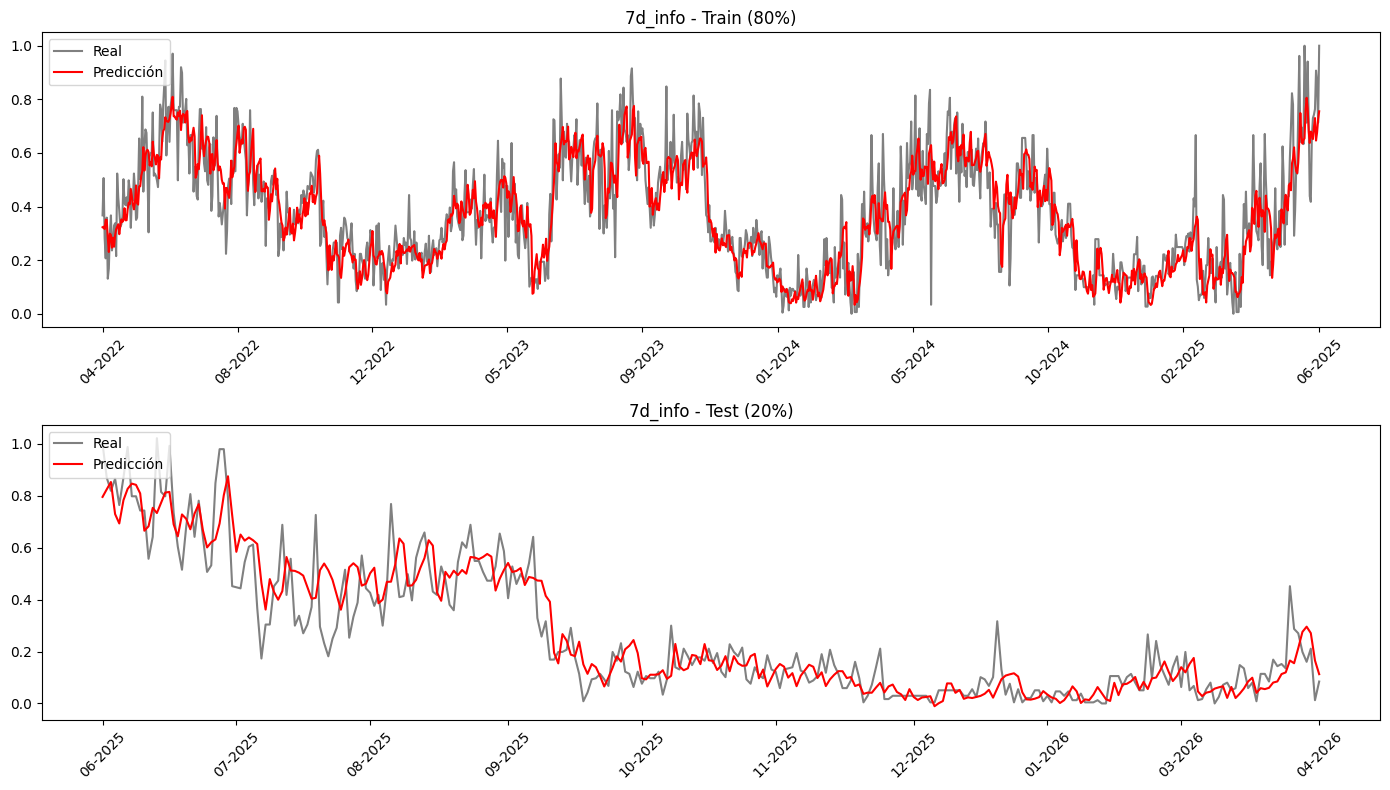


DATASET: 14d_no_info
Fold 1
  RMSE: 0.1120 | MAE: 0.0826 | MAPE: 18.76
Fold 2
  RMSE: 0.0826 | MAE: 0.0639 | MAPE: 27.97
Fold 3
  RMSE: 0.0972 | MAE: 0.0722 | MAPE: 21.38
Fold 4
  RMSE: 0.1300 | MAE: 0.0998 | MAPE: 17.53
Fold 5
  RMSE: 0.0833 | MAE: 0.0617 | MAPE: 15.71
Fold 6
  RMSE: 0.0973 | MAE: 0.0760 | MAPE: 45.54
Fold 7
  RMSE: 0.1338 | MAE: 0.0997 | MAPE: 19.41
Fold 8
  RMSE: 0.0869 | MAE: 0.0668 | MAPE: 19.83
Fold 9
  RMSE: 0.0727 | MAE: 0.0449 | MAPE: 26.33
Fold 10
  RMSE: 0.1489 | MAE: 0.1156 | MAPE: 28.54


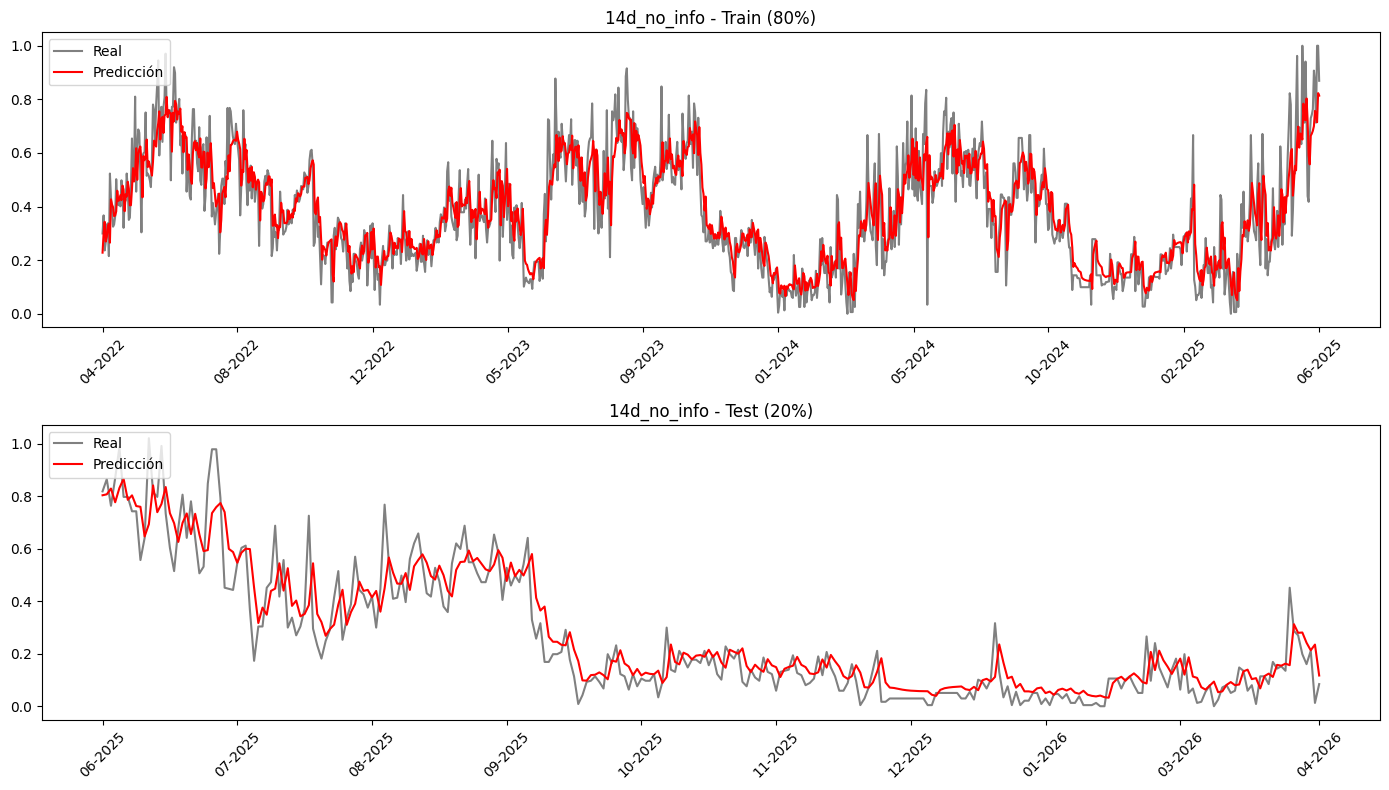


DATASET: 14d_info
Fold 1
  RMSE: 0.1855 | MAE: 0.1522 | MAPE: 34.56
Fold 2
  RMSE: 0.1018 | MAE: 0.0795 | MAPE: 34.80
Fold 3
  RMSE: 0.1096 | MAE: 0.0874 | MAPE: 25.86
Fold 4
  RMSE: 0.1621 | MAE: 0.1293 | MAPE: 22.71
Fold 5
  RMSE: 0.1009 | MAE: 0.0753 | MAPE: 19.17
Fold 6
  RMSE: 0.1091 | MAE: 0.0887 | MAPE: 53.14
Fold 7
  RMSE: 0.1389 | MAE: 0.1074 | MAPE: 20.91
Fold 8
  RMSE: 0.1020 | MAE: 0.0833 | MAPE: 24.73
Fold 9
  RMSE: 0.0842 | MAE: 0.0603 | MAPE: 35.40
Fold 10
  RMSE: 0.1596 | MAE: 0.1221 | MAPE: 30.16


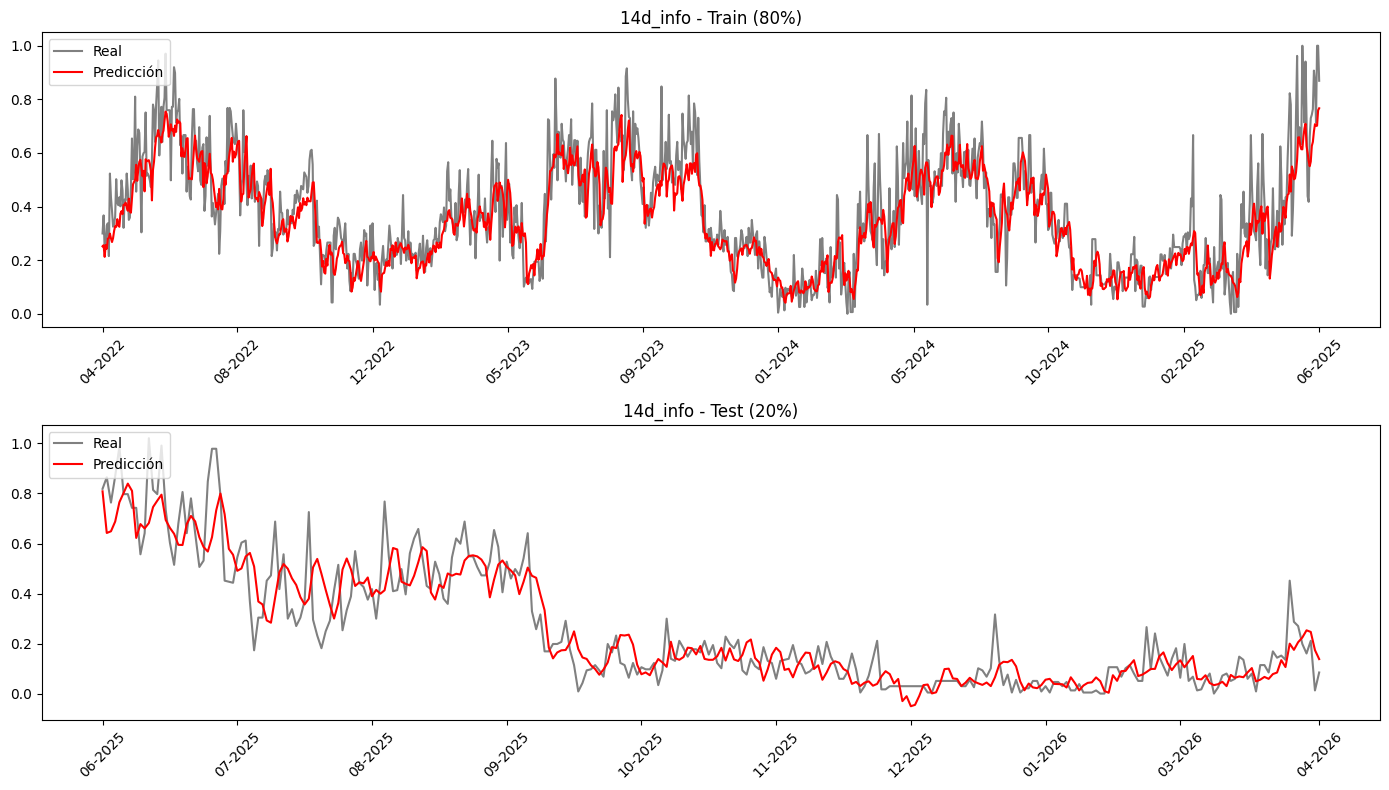

In [17]:
results = []
fold_results = []

for name, df in datasets.items():

    print(f"\n==============================")
    print(f"DATASET: {name}")
    print(f"==============================")

    X_train, X_test, y_train, y_test, scaler_y, dates_train, dates_test = prepare_data(df)

    fold_metrics = cross_validate_lstm_ts(X_train, y_train, best_params)

    for i, f in enumerate(fold_metrics):
        fold_results.append({
            "dataset": name,
            "fold": i+1,
            "rmse": f["rmse"],
            "mae": f["mae"],
            "mape": f["mape"]
        })

    avg_rmse = np.mean([f["rmse"] for f in fold_metrics])
    avg_mae = np.mean([f["mae"] for f in fold_metrics])
    avg_mape = np.mean([f["mape"] for f in fold_metrics])

    test_metrics, y_train_true, y_train_pred, y_test_true, y_test_pred = train_and_predict_train_test_lstm(
        X_train, y_train, X_test, y_test, scaler_y, best_params
    )

    results.append({
        "dataset": name,
        "cv_rmse": avg_rmse,
        "cv_mae": avg_mae,
        "cv_mape": avg_mape,
        "test_rmse": test_metrics["rmse"],
        "test_mae": test_metrics["mae"],
        "test_mape": test_metrics["mape"]
    })

    plot_train_test(
        dates_train,
        dates_test,
        y_train_true,
        y_train_pred,
        y_test_true,
        y_test_pred,
        title=name
    )

In [18]:
results_df = pd.DataFrame(results)
folds_df = pd.DataFrame(fold_results)

print("\n===== RESULTADOS FINALES =====")
display(results_df)

print("\n===== RESULTADOS POR FOLD =====")
display(folds_df)


===== RESULTADOS FINALES =====


,dataset,cv_rmse,cv_mae,cv_mape,test_rmse,test_mae,test_mape
0,7d_no_info,0.102953,0.077113,23.607468,0.097208,0.073045,27.552194
1,7d_info,0.123597,0.096925,29.997835,0.103522,0.075265,28.389430
2,14d_no_info,0.104474,0.078311,24.099335,0.094992,0.068798,26.410415
3,14d_info,0.125361,0.098541,30.142481,0.106241,0.077599,29.788621



===== RESULTADOS POR FOLD =====


,dataset,fold,rmse,mae,mape
0,7d_no_info,1,0.104524,0.076737,17.315892
1,7d_no_info,2,0.077324,0.060169,26.519862
2,7d_no_info,3,0.096983,0.072938,21.644054
3,7d_no_info,4,0.134495,0.104647,18.482234
4,7d_no_info,5,0.085712,0.061189,15.350006
5,7d_no_info,6,0.092564,0.070480,42.751642
6,7d_no_info,7,0.134873,0.102167,19.937372
7,7d_no_info,8,0.090641,0.068906,20.210146
8,7d_no_info,9,0.071319,0.043490,25.555113
9,7d_no_info,10,0.141093,0.110407,28.308361


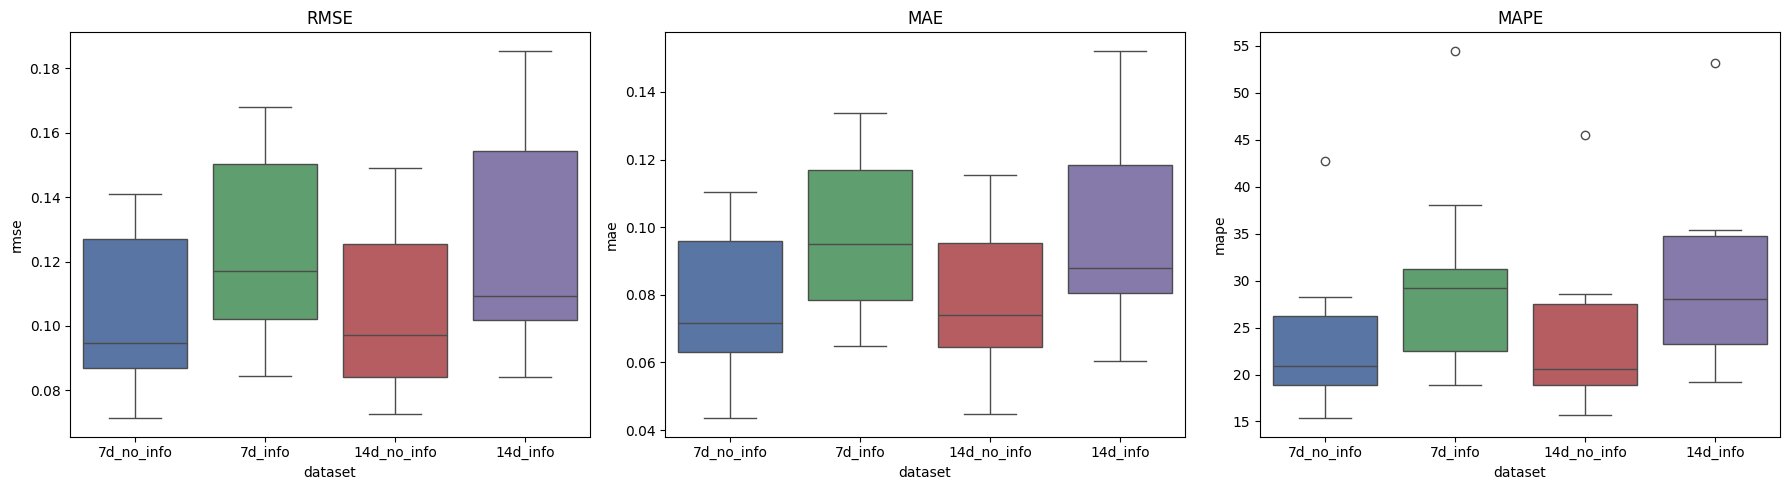

In [19]:
plot_boxplots(folds_df)

In [20]:
folds_df.to_csv("folds_lstm.csv", index=False)
results_df.to_csv("results_lstm.csv")